# Fine-Tuning EfficientNet-B3 (Binary Classifier)

This notebook picks up the best-performing base model from the model comparison (EfficientNet-B3) and fine-tunes it to improve **F1 and recall on the Malignant class**, using three techniques:

1. **Class-weighted loss** — corrects the imbalance-driven bias between Benign/Malignant
2. **Discriminative fine-tuning** — unfreeze the last few backbone blocks with a low LR, head with a higher LR
3. **Threshold tuning** — move the decision boundary off 0.5 using the precision-recall curve instead of retraining further

## Setup

In [1]:
import sys
sys.path.insert(0, "../../src/python/")

In [2]:
import os
import pickle
import warnings
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b3
from torchvision.models import EfficientNet_B3_Weights

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
VAL_IMAGE_DIR   = "/home/shadeform/data/test/"

TRAIN_LABEL_FILE = "/home/shadeform/data/labels/binary_train.pkl"
VAL_LABEL_FILE   = "/home/shadeform/data/labels/binary_val.pkl"

IMAGE_SIZE = 300
BATCH_SIZE = 32
NUM_CLASSES = 2

# Fine-tuning hyperparameters
FT_EPOCHS = 15
HEAD_LR = 1e-4
BACKBONE_LR = 1e-5
UNFREEZE_BLOCKS = 3   # unfreeze the last N blocks of model.features

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Load Base Checkpoint (from prior training run)

Pulls the best EfficientNet-B3 checkpoint saved earlier. If it isn't present locally, it's pulled from S3.

In [4]:
import boto3

BUCKET_NAME = "skin-lesion-data-bucket"
BASE_CHECKPOINT_S3_KEY = "saved_models/efficientnet_b3_binary/efficientnet_b3_binary_checkpoint.pth"
BASE_CHECKPOINT_LOCAL = "efficientnet_b3_binary_checkpoint.pth"

if not os.path.exists(BASE_CHECKPOINT_LOCAL):
    s3 = boto3.client("s3")
    s3.download_file(BUCKET_NAME, BASE_CHECKPOINT_S3_KEY, BASE_CHECKPOINT_LOCAL)
    print("Downloaded base checkpoint from S3")
else:
    print("Base checkpoint already present locally")

Downloaded base checkpoint from S3


## Load Labels & Compute Class Weights

In [5]:
with open(TRAIN_LABEL_FILE, "rb") as f:
    binary_train = pickle.load(f)

with open(VAL_LABEL_FILE, "rb") as f:
    binary_val = pickle.load(f)

print(len(binary_train), len(binary_val))

30931 8238


In [6]:
y_train = np.array(list(binary_train.values()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class Weights [Benign, Malignant] :", class_weights)

Class Weights [Benign, Malignant] : tensor([0.7433, 1.5276], device='cuda:0')


## Transforms

In [7]:
weights = EfficientNet_B3_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25)])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

## Dataset Class

In [8]:
class BinaryDataset(Dataset):

    def __init__(self, image_dir, mapping_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        with open(mapping_file, "rb") as f:
            self.labels = pickle.load(f)

        self.image_names = list(self.labels.keys())
        print("Images :", len(self.image_names))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        if "." in image_name:
            filename = image_name
        else:
            filename = image_name + ".jpg"
        image_path = os.path.join(self.image_dir, filename)

        if not os.path.exists(image_path):
            filename = image_name + ".png"
            image_path = os.path.join(self.image_dir, filename)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.labels[image_name]
        label = int(label)

        return image, label

## Dataset and DataLoader

In [9]:
train_dataset = BinaryDataset(TRAIN_IMAGE_DIR, TRAIN_LABEL_FILE, train_transform)
val_dataset = BinaryDataset(VAL_IMAGE_DIR, VAL_LABEL_FILE, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

print("Train Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))

Images : 30931
Images : 8238
Train Images : 30931
Validation Images : 8238


## Load Model + Base Weights

In [10]:
model = efficientnet_b3(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, NUM_CLASSES))

checkpoint = torch.load(BASE_CHECKPOINT_LOCAL, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(DEVICE)
print("Base checkpoint loaded. Previous best accuracy :", checkpoint.get("best_accuracy"))

Base checkpoint loaded. Previous best accuracy : 0.8092983733915999


## Discriminative Fine-Tuning Setup

Freeze the entire backbone, then unfreeze only the last `UNFREEZE_BLOCKS` feature blocks plus the classifier head. This lets the head adapt quickly while the unfrozen backbone layers adjust slowly, without disturbing the earlier low-level feature extractors that don't need to change.

In [11]:
for param in model.parameters():
    param.requires_grad = False

feature_blocks = list(model.features.children())

for block in feature_blocks[-UNFREEZE_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("Trainable Parameters :", trainable, "/", total, f"({trainable/total*100:.1f}%)")

Trainable Parameters : 8509152 / 10699306 (79.5%)


In [12]:
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "classifier" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": BACKBONE_LR},
    {"params": head_params, "lr": HEAD_LR}], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FT_EPOCHS)

## Class-Weighted Loss

In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

## Training

In [14]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()
    running_loss = 0
    predictions = []
    targets = []
    loop = tqdm(loader)

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(targets, predictions)
    return epoch_loss, epoch_acc

## Validation Function

In [15]:
def validate(model, loader, criterion):

    model.eval()
    running_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(targets, predictions)
    return epoch_loss, epoch_acc, predictions, targets

## Fine-Tuning Loop

Tracks Malignant recall alongside accuracy, and checkpoints on whichever epoch has the best **malignant F1** rather than raw accuracy — since that's the metric we're actually trying to improve.

In [16]:
from sklearn.metrics import f1_score, recall_score

best_malignant_f1 = 0
patience = 6
counter = 0
history_train_loss = []
history_val_loss = []
history_train_acc = []
history_val_acc = []
history_malignant_recall = []
history_malignant_f1 = []

for epoch in range(FT_EPOCHS):
    print("Epoch", epoch + 1, "/", FT_EPOCHS)
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, preds, targets = validate(model, val_loader, criterion)
    scheduler.step()

    malignant_recall = recall_score(targets, preds, pos_label=1)
    malignant_f1 = f1_score(targets, preds, pos_label=1)

    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_train_acc.append(train_acc)
    history_val_acc.append(val_acc)
    history_malignant_recall.append(malignant_recall)
    history_malignant_f1.append(malignant_f1)

    print()
    print("Train Loss :", round(train_loss, 4))
    print("Train Accuracy :", round(train_acc * 100, 2), "%")
    print()
    print("Validation Loss :", round(val_loss, 4))
    print("Validation Accuracy :", round(val_acc * 100, 2), "%")
    print("Malignant Recall :", round(malignant_recall, 4))
    print("Malignant F1 :", round(malignant_f1, 4))
    print()
    min_delta = 0.001

    if malignant_f1 > best_malignant_f1 + min_delta:
        best_malignant_f1 = malignant_f1
        counter = 0
        torch.save(model.state_dict(), "best_binary_efficientnet_b3_finetuned.pth")
        print("Best Model Saved (Malignant F1 :", round(malignant_f1, 4), ")")
    else:
        counter += 1
        print("Early Stopping Counter :", counter)

    if counter >= patience:
        print()
        print("Early Stopping")
        break

Epoch 1 / 15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:33<00:00, 10.37it/s, loss=0.469]



Train Loss : 0.4681
Train Accuracy : 83.01 %

Validation Loss : 0.4313
Validation Accuracy : 81.05 %
Malignant Recall : 0.8818
Malignant F1 : 0.8467

Best Model Saved (Malignant F1 : 0.8467 )
Epoch 2 / 15


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:33<00:00, 10.32it/s, loss=0.37]



Train Loss : 0.4617
Train Accuracy : 83.38 %

Validation Loss : 0.4369
Validation Accuracy : 81.26 %
Malignant Recall : 0.8693
Malignant F1 : 0.8462

Early Stopping Counter : 1
Epoch 3 / 15


...


Train Loss : 0.4512
Train Accuracy : 84.35 %

Validation Loss : 0.4405
Validation Accuracy : 80.32 %
Malignant Recall : 0.8627
Malignant F1 : 0.8388

Early Stopping Counter : 4
Epoch 6 / 15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:51<00:00,  8.67it/s, loss=0.435]



Train Loss : 0.4497
Train Accuracy : 84.26 %

Validation Loss : 0.4516
Validation Accuracy : 80.01 %
Malignant Recall : 0.8394
Malignant F1 : 0.8328

Early Stopping Counter : 5
Epoch 7 / 15


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:50<00:00,  8.75it/s, loss=0.526]



Train Loss : 0.4461
Train Accuracy : 84.5 %

Validation Loss : 0.4527
Validation Accuracy : 80.27 %
Malignant Recall : 0.8464
Malignant F1 : 0.8358

Early Stopping Counter : 6

Early Stopping


## Metrics (Default 0.5 Threshold)

In [17]:
model.load_state_dict(
    torch.load("best_binary_efficientnet_b3_finetuned.pth", map_location=DEVICE))

model.eval()
predictions = []
targets = []
probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(DEVICE)
        outputs = model(images)
        p = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        probs.extend(p.cpu().numpy())
        targets.extend(labels.numpy())

targets = np.array(targets)
probs = np.array(probs)
predictions = np.array(predictions)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:18<00:00, 13.87it/s]


In [18]:
print("Validation Accuracy")
print()
print(accuracy_score(targets, predictions))
print()
print(classification_report(targets, predictions, target_names=["Benign", "Malignant"]))

Validation Accuracy

0.810512260257344

              precision    recall  f1-score   support

      Benign       0.80      0.71      0.75      3350
   Malignant       0.81      0.88      0.85      4888

    accuracy                           0.81      8238
   macro avg       0.81      0.79      0.80      8238
weighted avg       0.81      0.81      0.81      8238



In [19]:
cm = confusion_matrix(targets, predictions)
print(cm)

[[2367  983]
 [ 578 4310]]


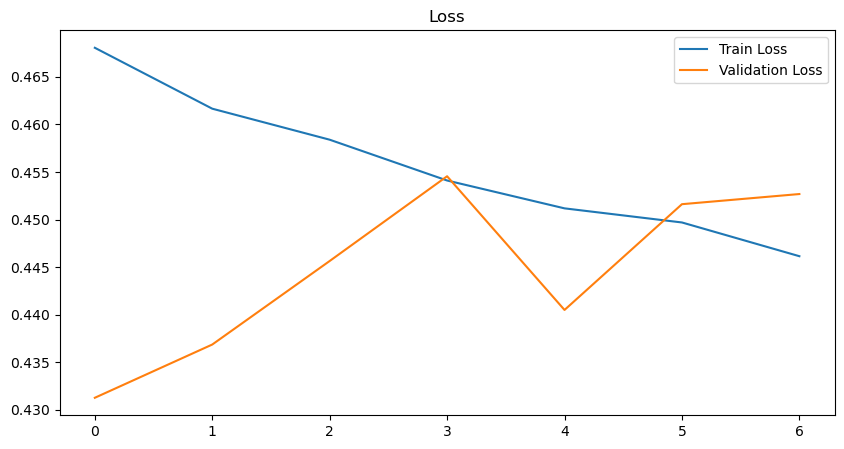

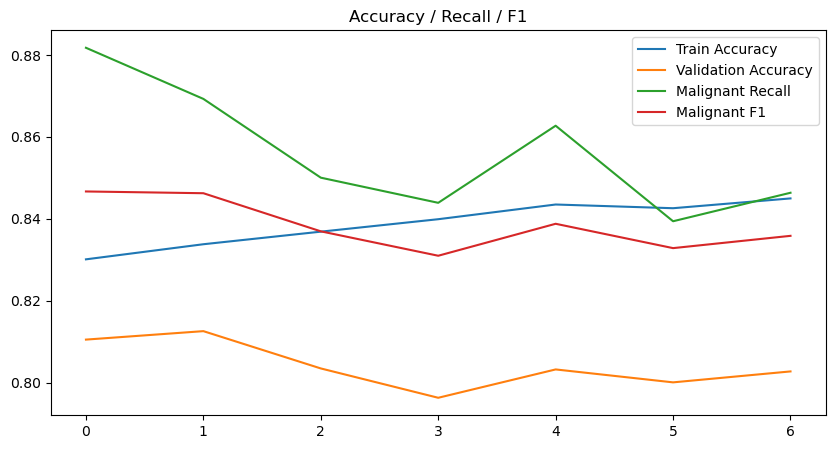

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history_train_loss, label="Train Loss")
plt.plot(history_val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_train_acc, label="Train Accuracy")
plt.plot(history_val_acc, label="Validation Accuracy")
plt.plot(history_malignant_recall, label="Malignant Recall")
plt.plot(history_malignant_f1, label="Malignant F1")
plt.legend()
plt.title("Accuracy / Recall / F1")
plt.show()

## Threshold Tuning

Instead of the default argmax (0.5 threshold), search the precision-recall curve for the malignant class to find a better operating point. This is free — no retraining required.

In [21]:
precisions, recalls, thresholds = precision_recall_curve(targets, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Threshold that maximizes F1
best_f1_idx = np.argmax(f1_scores[:-1])
best_f1_threshold = thresholds[best_f1_idx]

print("Best F1 Threshold :", round(best_f1_threshold, 4))
print("F1 at that threshold :", round(f1_scores[best_f1_idx], 4))
print("Precision at that threshold :", round(precisions[best_f1_idx], 4))
print("Recall at that threshold :", round(recalls[best_f1_idx], 4))

Best F1 Threshold : 0.4725
F1 at that threshold : 0.8481
Precision at that threshold : 0.8072
Recall at that threshold : 0.8934


In [22]:
# Threshold that guarantees a target malignant recall (useful for clinical screening
# where missing a cancer is far costlier than a false alarm)
TARGET_RECALL = 0.90

valid_idx = np.where(recalls[:-1] >= TARGET_RECALL)[0]

if len(valid_idx) > 0:
    high_recall_idx = valid_idx[np.argmax(precisions[valid_idx])]
    high_recall_threshold = thresholds[high_recall_idx]
    print(f"Threshold for >= {TARGET_RECALL*100:.0f}% Malignant Recall :", round(high_recall_threshold, 4))
    print("Precision at that threshold :", round(precisions[high_recall_idx], 4))
    print("Recall at that threshold :", round(recalls[high_recall_idx], 4))
else:
    print(f"No threshold in this model reaches {TARGET_RECALL*100:.0f}% recall")

Threshold for >= 90% Malignant Recall : 0.4507
Precision at that threshold : 0.7991
Recall at that threshold : 0.9002


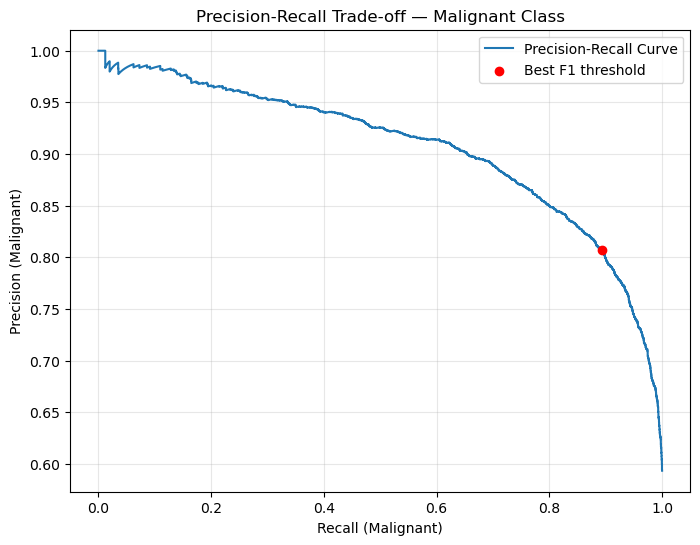

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_f1_idx], precisions[best_f1_idx], color="red", zorder=5, label="Best F1 threshold")
plt.xlabel("Recall (Malignant)")
plt.ylabel("Precision (Malignant)")
plt.title("Precision-Recall Trade-off — Malignant Class")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Re-Evaluate at Tuned Threshold

In [24]:
CHOSEN_THRESHOLD = best_f1_threshold  # swap for high_recall_threshold if you want max recall instead

tuned_predictions = (probs >= CHOSEN_THRESHOLD).astype(int)

print("Tuned Threshold :", round(CHOSEN_THRESHOLD, 4))
print()
print(classification_report(targets, tuned_predictions, target_names=["Benign", "Malignant"]))
print()
print(confusion_matrix(targets, tuned_predictions))

Tuned Threshold : 0.4725

              precision    recall  f1-score   support

      Benign       0.82      0.69      0.75      3350
   Malignant       0.81      0.89      0.85      4888

    accuracy                           0.81      8238
   macro avg       0.81      0.79      0.80      8238
weighted avg       0.81      0.81      0.81      8238


[[2307 1043]
 [ 521 4367]]


## Saving Fine-Tuned Model to S3

In [25]:
os.makedirs("saved_models/efficientnet_b3_binary_finetuned", exist_ok=True)

torch.save(
    {"model_state_dict": model.state_dict(),
     "optimizer_state_dict": optimizer.state_dict(),
     "scheduler_state_dict": scheduler.state_dict(),
     "best_malignant_f1": best_malignant_f1,
     "chosen_threshold": float(CHOSEN_THRESHOLD),
     "epochs": FT_EPOCHS},
    "saved_models/efficientnet_b3_binary_finetuned/efficientnet_b3_binary_finetuned_checkpoint.pth")

In [26]:
MODEL_FOLDER = "saved_models/efficientnet_b3_binary_finetuned"
s3 = boto3.client("s3")
local_file = "saved_models/efficientnet_b3_binary_finetuned/efficientnet_b3_binary_finetuned_checkpoint.pth"
s3_key = f"{MODEL_FOLDER}/efficientnet_b3_binary_finetuned_checkpoint.pth"

s3.upload_file(local_file, BUCKET_NAME, s3_key)

print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

Uploaded -> s3://skin-lesion-data-bucket/saved_models/efficientnet_b3_binary_finetuned/efficientnet_b3_binary_finetuned_checkpoint.pth
